# Basic Statistics Assignment

**Topic:** Descriptive Analytics and Data Preprocessing on Sales & Discounts Dataset

This notebook covers:
- Loading the dataset
- Descriptive statistics for numerical columns
- Histograms, boxplots, and bar charts
- Standardization using Z-score normalization
- One-hot encoding for categorical columns
- Final conclusion


In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Show plots inside notebook
%matplotlib inline

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)


In [3]:
# Load the dataset
# Make sure the CSV file is in the same folder as this notebook
df = pd.read_csv("sales_data_with_discounts.csv")

# Display first 5 rows
df.head()


,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770


In [4]:
# Check dataset shape
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])


Number of rows: 450
Number of columns: 13


In [5]:
# Check column names and data types
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               450 non-null    object 
 1   Day                450 non-null    object 
 2   SKU                450 non-null    object 
 3   City               450 non-null    object 
 4   Volume             450 non-null    int64  
 5   BU                 450 non-null    object 
 6   Brand              450 non-null    object 
 7   Model              450 non-null    object 
 8   Avg Price          450 non-null    int64  
 9   Total Sales Value  450 non-null    int64  
 10  Discount Rate (%)  450 non-null    float64
 11  Discount Amount    450 non-null    float64
 12  Net Sales Value    450 non-null    float64
dtypes: float64(3), int64(3), object(7)
memory usage: 45.8+ KB


## 1. Identifying Numerical and Categorical Columns

In [6]:
# Identify numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Numerical Columns:")
print(list(numerical_cols))

print("\nCategorical Columns:")
print(list(categorical_cols))


Numerical Columns:
['Volume', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)', 'Discount Amount', 'Net Sales Value']

Categorical Columns:
['Date', 'Day', 'SKU', 'City', 'BU', 'Brand', 'Model']


## 2. Descriptive Analytics for Numerical Columns

We calculate:
- Mean
- Median
- Mode
- Standard Deviation


In [7]:
# Calculate descriptive statistics
stats_summary = pd.DataFrame({
    "Mean": df[numerical_cols].mean(),
    "Median": df[numerical_cols].median(),
    "Mode": df[numerical_cols].mode().iloc[0],
    "Standard Deviation": df[numerical_cols].std()
})

stats_summary


,Mean,Median,Mode,Standard Deviation
Volume,5.066667,4.000000,3.000000,4.231602
Avg Price,10453.433333,1450.000000,400.000000,18079.904840
Total Sales Value,33812.835556,5700.000000,24300.000000,50535.074173
Discount Rate (%),15.155242,16.577766,5.007822,4.220602
Discount Amount,3346.499424,988.933733,69.177942,4509.902963
Net Sales Value,30466.336131,4677.788059,326.974801,46358.656624


In [8]:
# Basic interpretation helper
for col in numerical_cols:
    print(f"Column: {col}")
    print(f"Mean: {df[col].mean():.2f}")
    print(f"Median: {df[col].median():.2f}")
    print(f"Mode: {df[col].mode().iloc[0]}")
    print(f"Standard Deviation: {df[col].std():.2f}")

    if df[col].mean() > df[col].median():
        print("Interpretation: Distribution is likely right-skewed.")
    elif df[col].mean() < df[col].median():
        print("Interpretation: Distribution is likely left-skewed.")
    else:
        print("Interpretation: Distribution is approximately symmetric.")

    print("-" * 60)


Column: Volume
Mean: 5.07
Median: 4.00
Mode: 3
Standard Deviation: 4.23
Interpretation: Distribution is likely right-skewed.
------------------------------------------------------------
Column: Avg Price
Mean: 10453.43
Median: 1450.00
Mode: 400
Standard Deviation: 18079.90
Interpretation: Distribution is likely right-skewed.
------------------------------------------------------------
Column: Total Sales Value
Mean: 33812.84
Median: 5700.00
Mode: 24300
Standard Deviation: 50535.07
Interpretation: Distribution is likely right-skewed.
------------------------------------------------------------
Column: Discount Rate (%)
Mean: 15.16
Median: 16.58
Mode: 5.007822189204133
Standard Deviation: 4.22
Interpretation: Distribution is likely left-skewed.
------------------------------------------------------------
Column: Discount Amount
Mean: 3346.50
Median: 988.93
Mode: 69.17794228822787
Standard Deviation: 4509.90
Interpretation: Distribution is likely right-skewed.
----------------------------

## 3. Histograms for Numerical Columns

Histograms help us understand:
- Distribution shape
- Skewness
- Spread of values
- Possible outliers


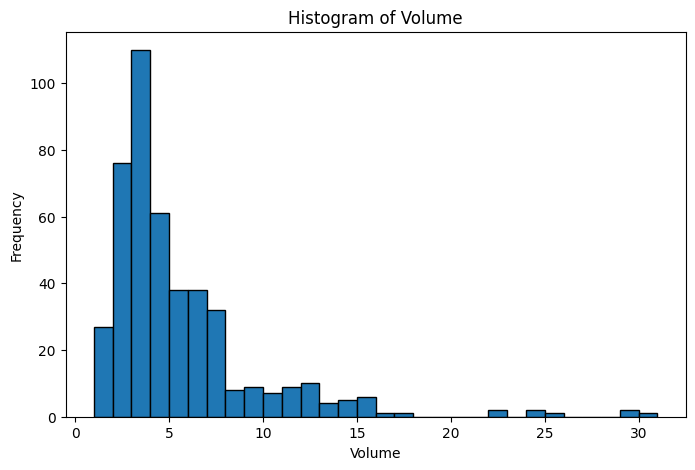

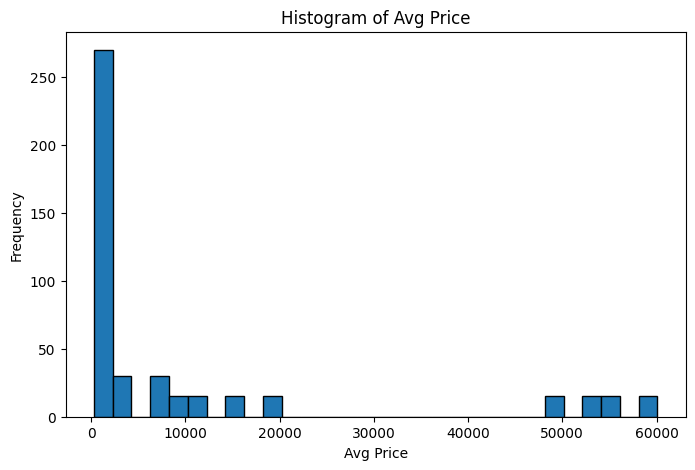

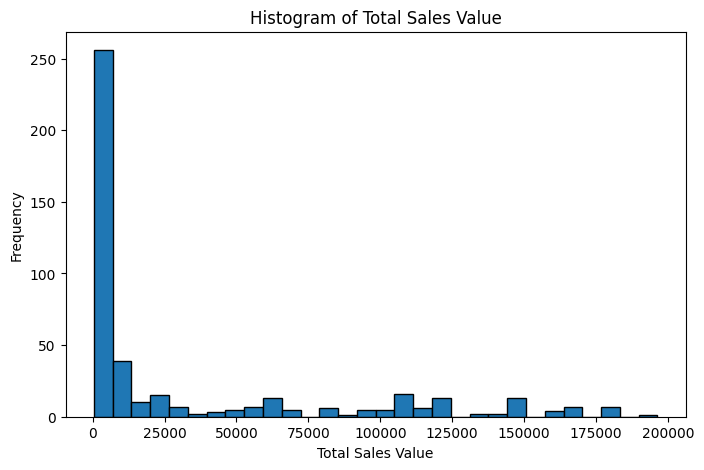

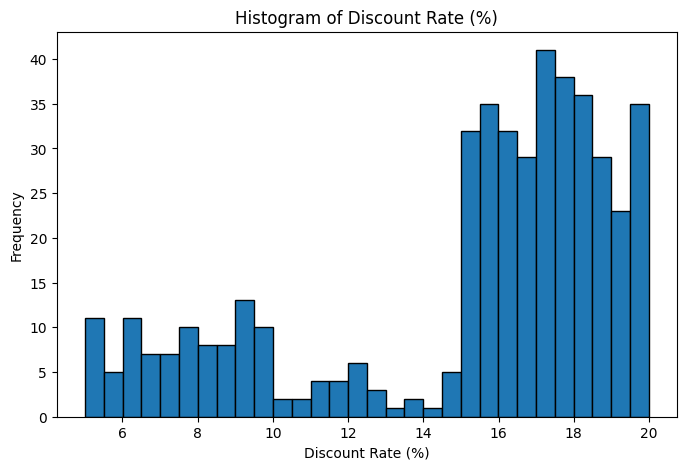

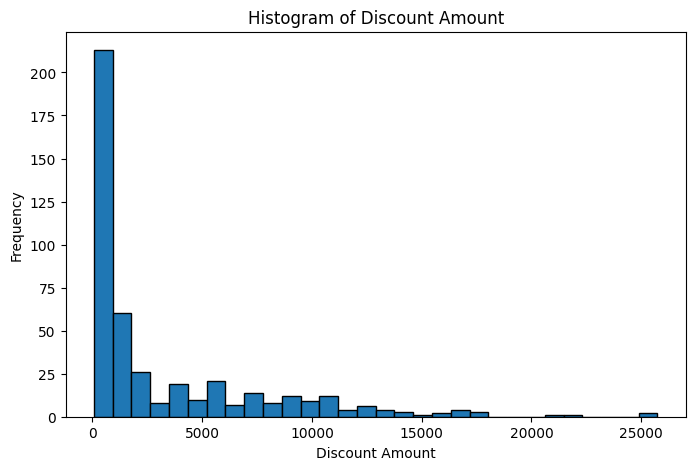

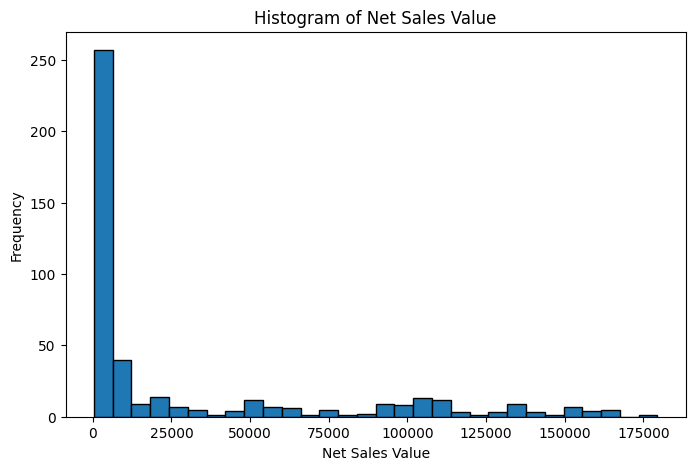

In [9]:
# Plot histograms for all numerical columns
for col in numerical_cols:
    plt.figure(figsize=(8, 5))
    plt.hist(df[col], bins=30, edgecolor='black')
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


In [10]:
# Skewness values
skewness = df[numerical_cols].skew()
skewness


Volume               2.731724
Avg Price            1.908873
Total Sales Value    1.534729
Discount Rate (%)   -1.062294
Discount Amount      1.913038
Net Sales Value      1.540822
dtype: float64

In [11]:
# Interpretation of skewness
for col in numerical_cols:
    skew_value = df[col].skew()
    print(f"{col}: Skewness = {skew_value:.2f}")

    if skew_value > 0.5:
        print("Inference: Positively/right skewed distribution.")
    elif skew_value < -0.5:
        print("Inference: Negatively/left skewed distribution.")
    else:
        print("Inference: Approximately symmetric distribution.")

    print("-" * 60)


Volume: Skewness = 2.73
Inference: Positively/right skewed distribution.
------------------------------------------------------------
Avg Price: Skewness = 1.91
Inference: Positively/right skewed distribution.
------------------------------------------------------------
Total Sales Value: Skewness = 1.53
Inference: Positively/right skewed distribution.
------------------------------------------------------------
Discount Rate (%): Skewness = -1.06
Inference: Negatively/left skewed distribution.
------------------------------------------------------------
Discount Amount: Skewness = 1.91
Inference: Positively/right skewed distribution.
------------------------------------------------------------
Net Sales Value: Skewness = 1.54
Inference: Positively/right skewed distribution.
------------------------------------------------------------


## 4. Boxplots for Numerical Columns

Boxplots help us identify:
- Median
- Interquartile range
- Outliers
- Extreme values


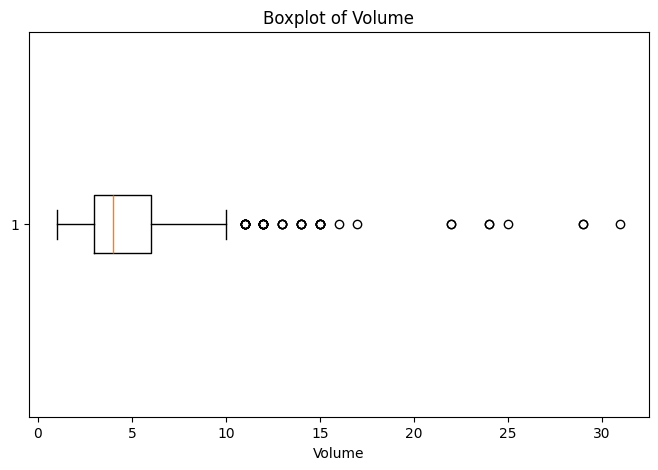

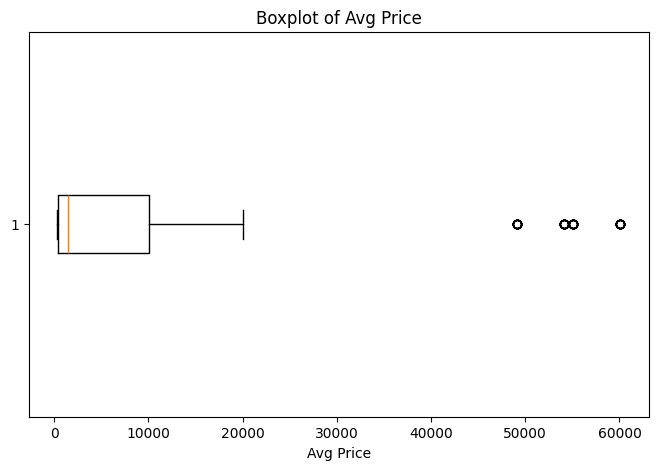

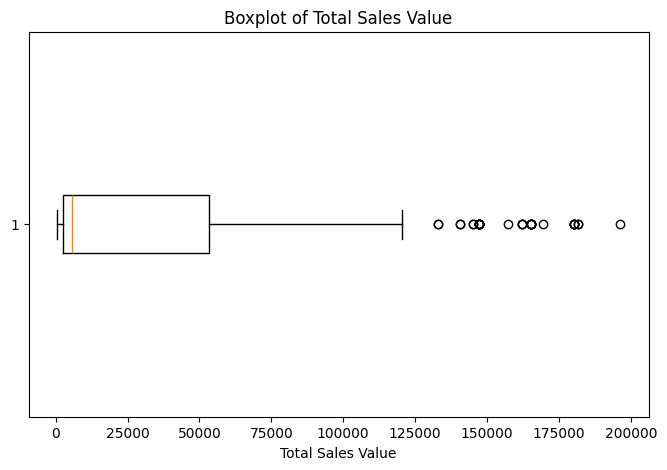

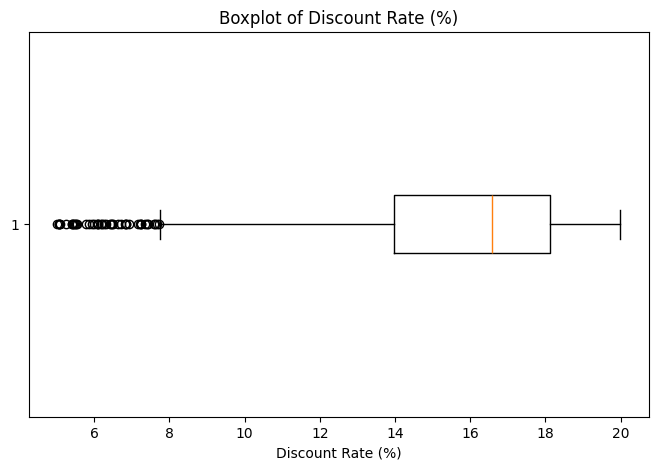

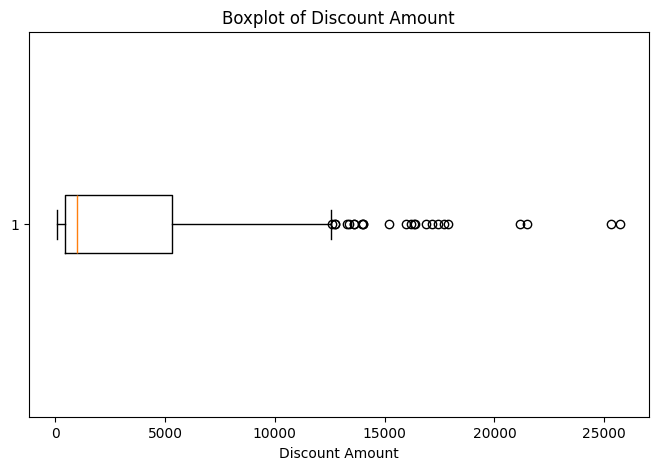

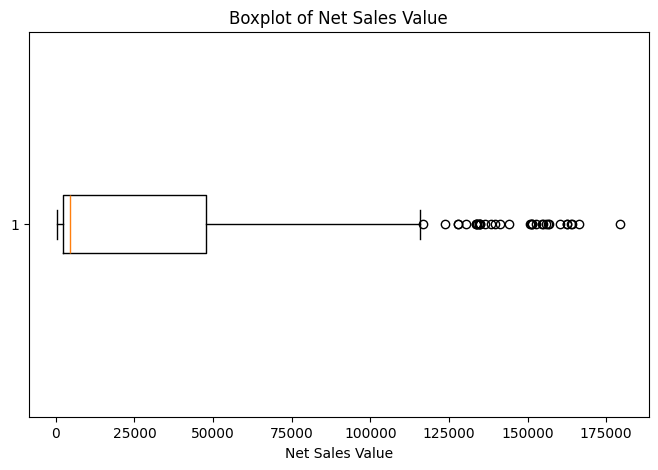

In [12]:
# Plot boxplots for numerical columns
for col in numerical_cols:
    plt.figure(figsize=(8, 5))
    plt.boxplot(df[col], vert=False)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()


In [13]:
# Function to detect outliers using IQR method
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]

    return Q1, Q3, IQR, lower_bound, upper_bound, len(outliers)

# Outlier summary
outlier_summary = []

for col in numerical_cols:
    Q1, Q3, IQR, lower, upper, count = detect_outliers_iqr(df, col)
    outlier_summary.append([col, Q1, Q3, IQR, lower, upper, count])

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=["Column", "Q1", "Q3", "IQR", "Lower Bound", "Upper Bound", "Outlier Count"]
)

outlier_df


,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,Volume,3.000000,6.000000,3.000000,-1.500000,10.500000,44
1,Avg Price,465.000000,10100.000000,9635.000000,-13987.500000,24552.500000,60
2,Total Sales Value,2700.000000,53200.000000,50500.000000,-73050.000000,128950.000000,36
3,Discount Rate (%),13.965063,18.114718,4.149656,7.740579,24.339202,45
4,Discount Amount,460.459304,5316.495427,4856.036123,-6823.594880,12600.549611,24
5,Net Sales Value,2202.208645,47847.912852,45645.704206,-66266.347664,116316.469161,35


## 5. Bar Chart Analysis for Categorical Columns

Bar charts help us understand the frequency/count of each category.


In [14]:
# Frequency count for categorical columns
for col in categorical_cols:
    print(f"Value counts for {col}:")
    print(df[col].value_counts())
    print("-" * 80)


Value counts for Date:
Date
01-04-2021    30
02-04-2021    30
03-04-2021    30
04-04-2021    30
05-04-2021    30
06-04-2021    30
07-04-2021    30
08-04-2021    30
09-04-2021    30
10-04-2021    30
11-04-2021    30
12-04-2021    30
13-04-2021    30
14-04-2021    30
15-04-2021    30
Name: count, dtype: int64
--------------------------------------------------------------------------------
Value counts for Day:
Day
Thursday     90
Friday       60
Saturday     60
Sunday       60
Monday       60
Tuesday      60
Wednesday    60
Name: count, dtype: int64
--------------------------------------------------------------------------------
Value counts for SKU:
SKU
M01    15
M02    15
M03    15
M04    15
M05    15
M06    15
M07    15
M08    15
M09    15
M10    15
F01    15
F02    15
F03    15
F04    15
F05    15
F06    15
F07    15
F08    15
F09    15
F10    15
L01    15
L02    15
L03    15
L04    15
L05    15
L06    15
L07    15
L08    15
L09    15
L10    15
Name: count, dtype: int64
-------------

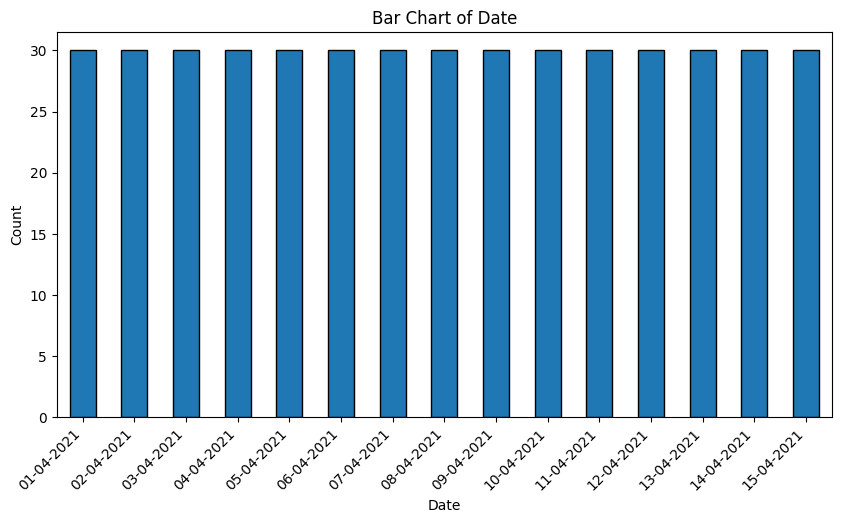

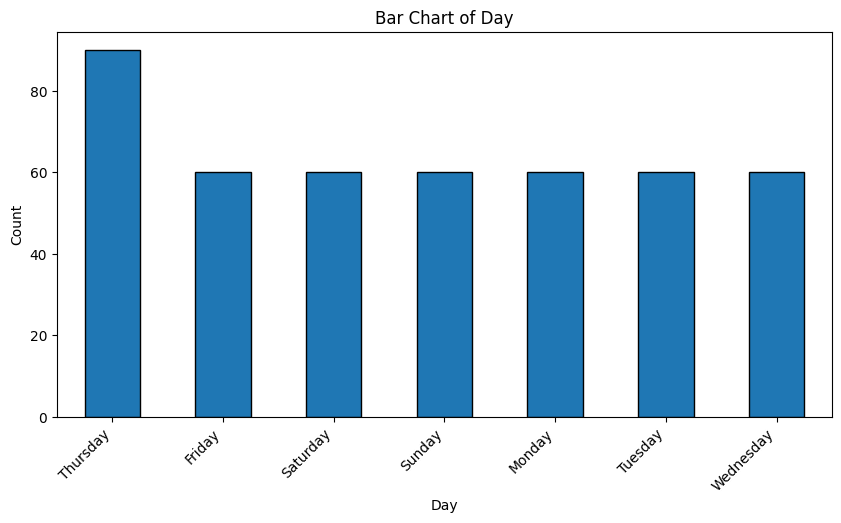

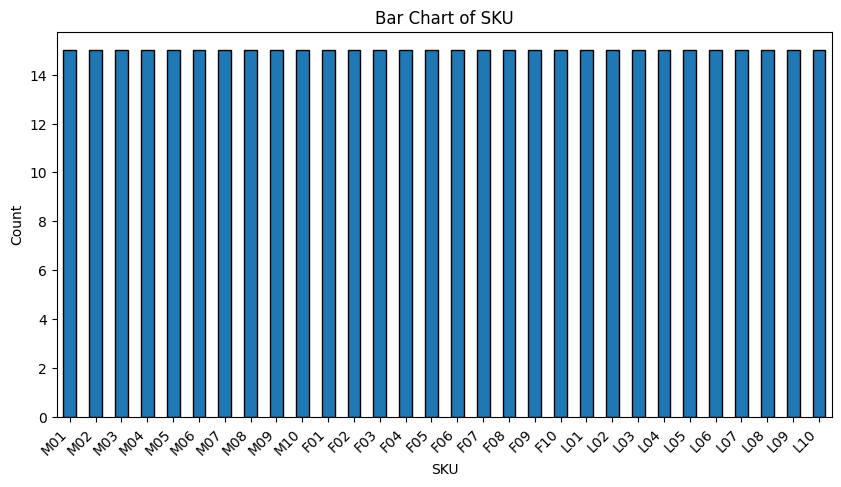

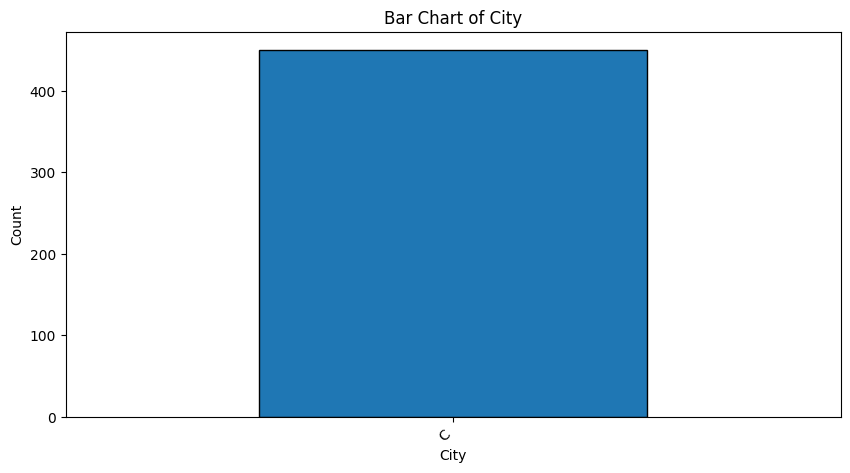

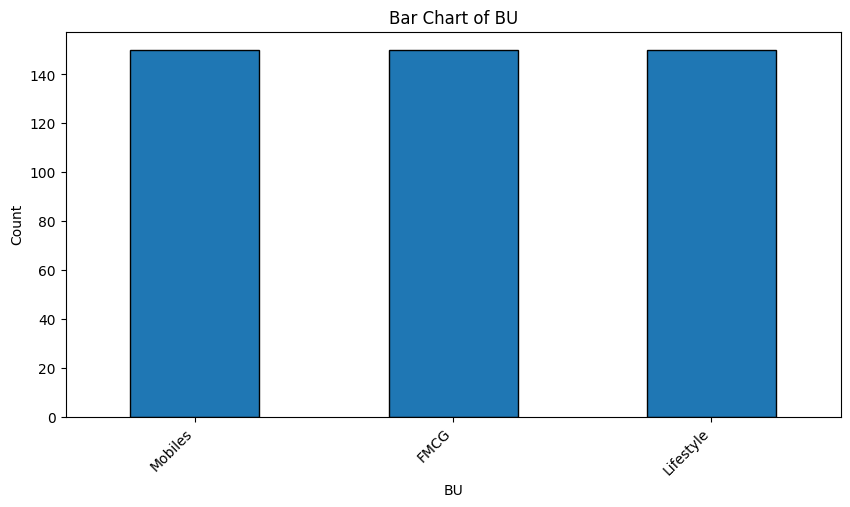

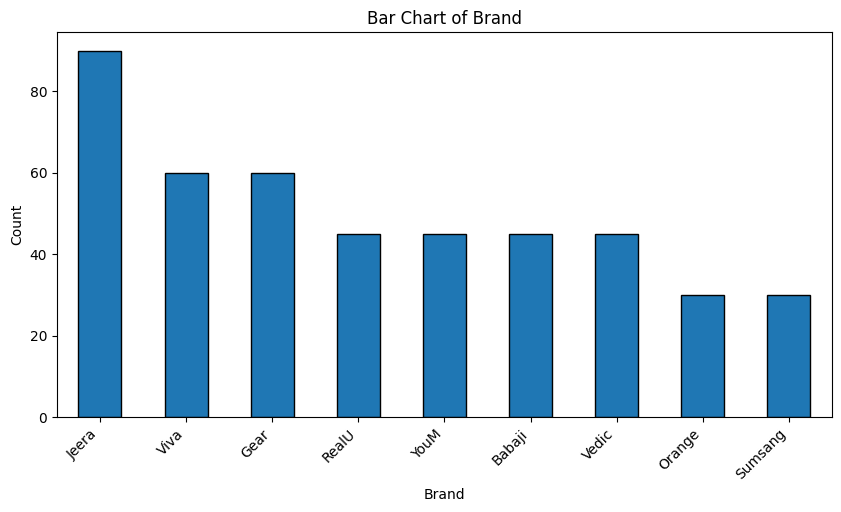

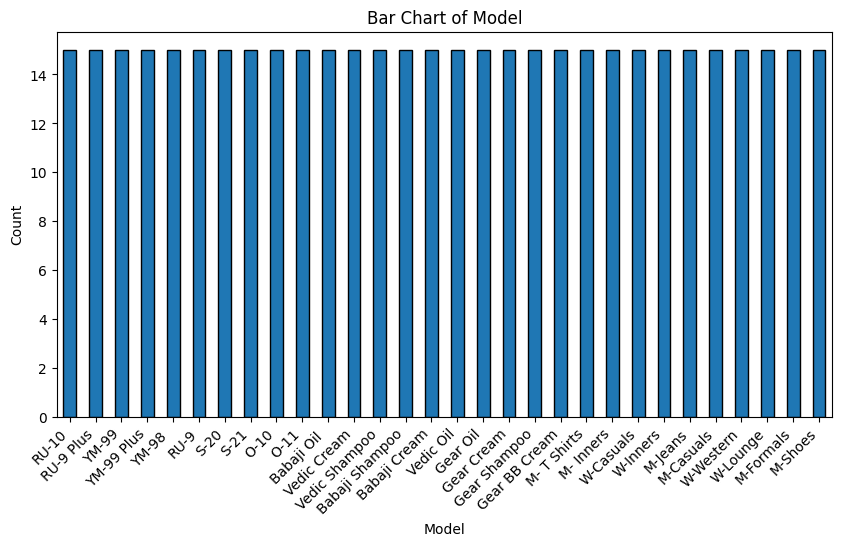

In [15]:
# Bar charts for categorical columns
for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    df[col].value_counts().plot(kind='bar', edgecolor='black')
    plt.title(f"Bar Chart of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha='right')
    plt.show()


## 6. Standardization of Numerical Variables

Standardization is also called **Z-score normalization**.

Formula:

\[
z = \frac{x - \mu}{\sigma}
\]

Where:
- \(x\) = original value
- \(\mu\) = mean
- \(\sigma\) = standard deviation

After standardization:
- Mean becomes approximately 0
- Standard deviation becomes approximately 1


In [16]:
# Copy original dataset
df_standardized = df.copy()

# Standardize numerical columns
df_standardized[numerical_cols] = (df[numerical_cols] - df[numerical_cols].mean()) / df[numerical_cols].std()

# Display standardized numerical columns
df_standardized[numerical_cols].head()


,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,2.347417,0.091072,2.922469,-0.829365,3.948422,2.801638
1,1.165831,-0.019548,1.329516,-0.851714,1.846958,1.269613
2,0.456880,0.312312,1.561038,-1.350129,1.621190,1.543957
3,0.220563,0.533552,1.717365,-1.947555,1.112568,1.763847
4,-0.488389,-0.130168,-0.188242,0.672990,0.227598,-0.227342


In [17]:
# Before standardization
print("Before Standardization:")
display(df[numerical_cols].head())

# After standardization
print("After Standardization:")
display(df_standardized[numerical_cols].head())


Before Standardization:


,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,15,12100,181500,11.654820,21153.498820,160346.501180
1,10,10100,101000,11.560498,11676.102961,89323.897039
2,7,16100,112700,9.456886,10657.910157,102042.089843
3,6,20100,120600,6.935385,8364.074702,112235.925298
4,3,8100,24300,17.995663,4372.946230,19927.053770


After Standardization:


,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,2.347417,0.091072,2.922469,-0.829365,3.948422,2.801638
1,1.165831,-0.019548,1.329516,-0.851714,1.846958,1.269613
2,0.456880,0.312312,1.561038,-1.350129,1.621190,1.543957
3,0.220563,0.533552,1.717365,-1.947555,1.112568,1.763847
4,-0.488389,-0.130168,-0.188242,0.672990,0.227598,-0.227342


In [18]:
# Check mean and standard deviation after standardization
standardized_check = pd.DataFrame({
    "Mean After Standardization": df_standardized[numerical_cols].mean(),
    "Std After Standardization": df_standardized[numerical_cols].std()
})

standardized_check


,Mean After Standardization,Std After Standardization
Volume,4.144833e-17,1.0
Avg Price,4.342206e-17,1.0
Total Sales Value,1.578984e-17,1.0
Discount Rate (%),-4.144833e-17,1.0
Discount Amount,-6.315935e-17,1.0
Net Sales Value,1.973730e-17,1.0


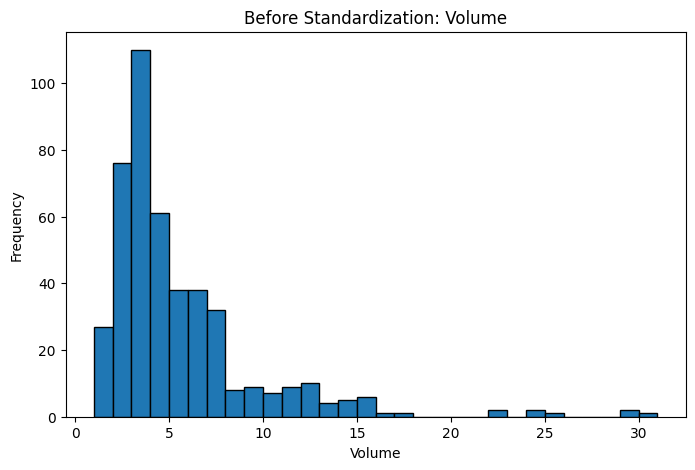

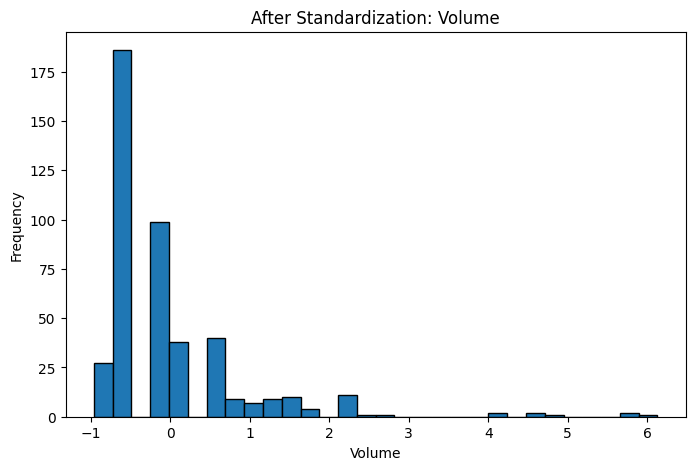

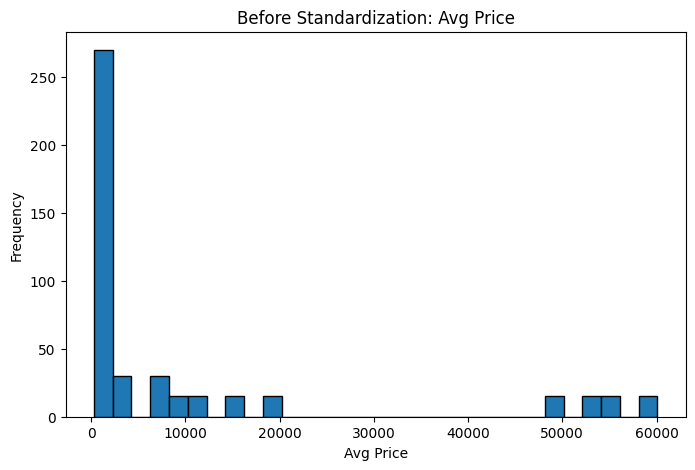

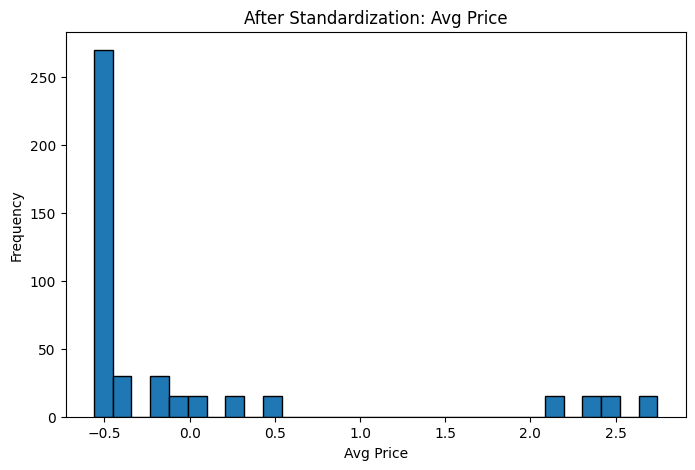

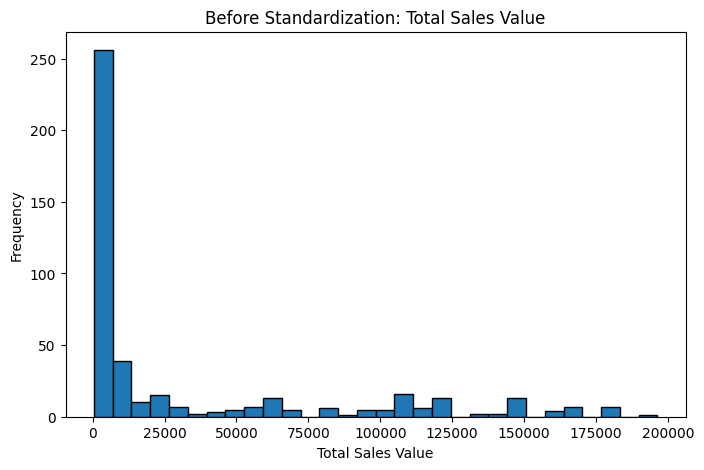

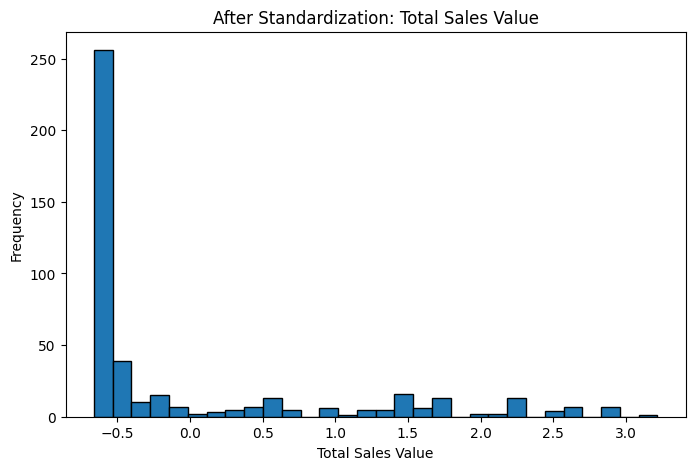

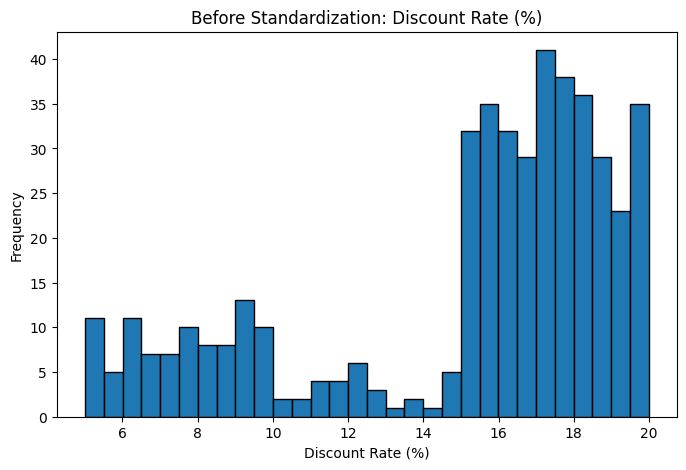

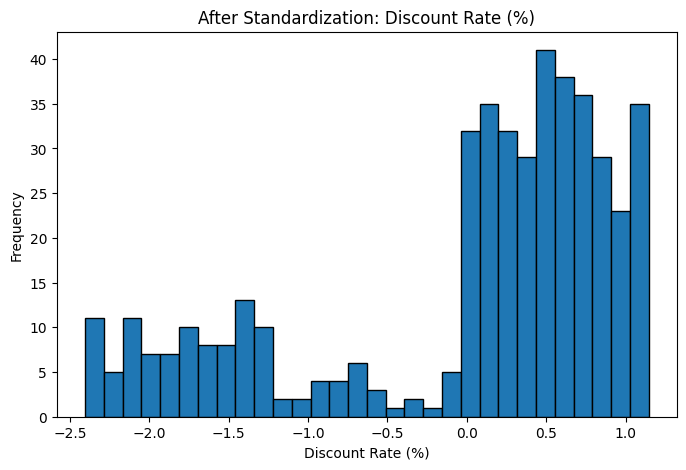

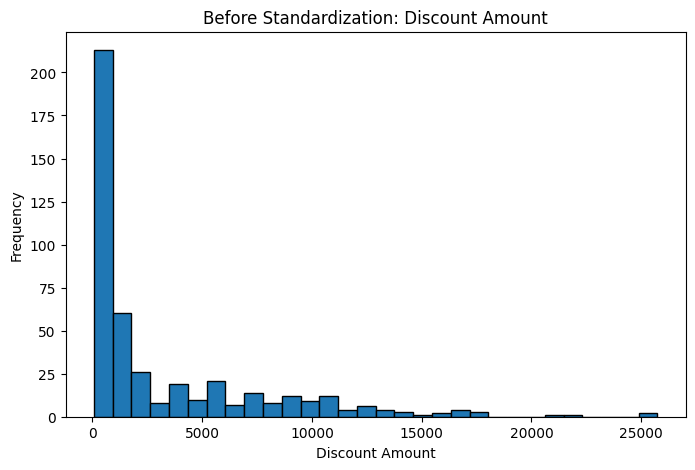

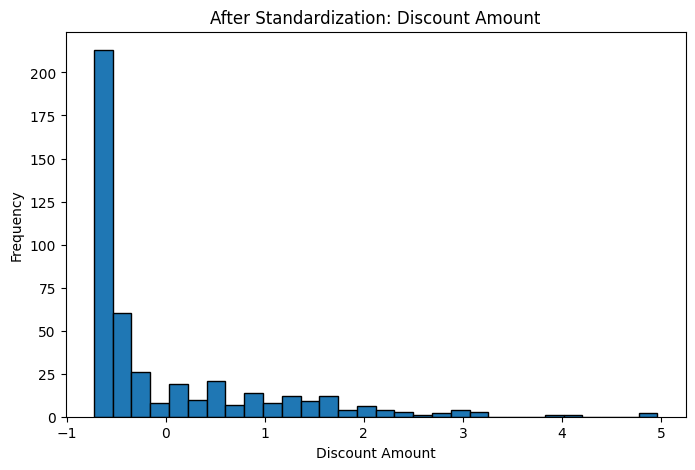

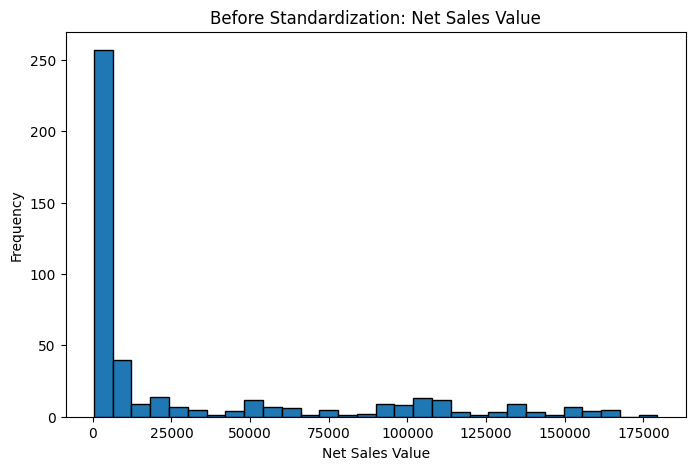

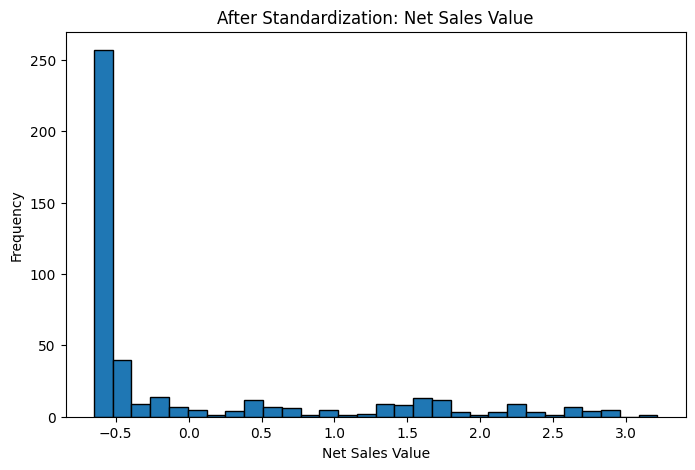

In [19]:
# Compare original and standardized distributions
for col in numerical_cols:
    plt.figure(figsize=(8, 5))
    plt.hist(df[col], bins=30, edgecolor='black')
    plt.title(f"Before Standardization: {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.hist(df_standardized[col], bins=30, edgecolor='black')
    plt.title(f"After Standardization: {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


## 7. Conversion of Categorical Data into Dummy Variables

Machine learning algorithms cannot directly process text/category values.

So categorical columns are converted into numerical binary columns using **one-hot encoding**.

Example:
- City = Mumbai, Pune, Delhi

After one-hot encoding:
- City_Mumbai
- City_Pune
- City_Delhi

Each column contains 0 or 1.


In [20]:
# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=False)

# Display transformed dataset
df_encoded.head()


,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value,Date_01-04-2021,Date_02-04-2021,Date_03-04-2021,Date_04-04-2021,Date_05-04-2021,Date_06-04-2021,Date_07-04-2021,Date_08-04-2021,Date_09-04-2021,Date_10-04-2021,Date_11-04-2021,Date_12-04-2021,Date_13-04-2021,Date_14-04-2021,Date_15-04-2021,Day_Friday,Day_Monday,Day_Saturday,Day_Sunday,Day_Thursday,Day_Tuesday,Day_Wednesday,SKU_F01,SKU_F02,SKU_F03,SKU_F04,SKU_F05,SKU_F06,SKU_F07,SKU_F08,SKU_F09,SKU_F10,SKU_L01,SKU_L02,SKU_L03,SKU_L04,SKU_L05,SKU_L06,SKU_L07,SKU_L08,SKU_L09,SKU_L10,SKU_M01,SKU_M02,SKU_M03,SKU_M04,SKU_M05,SKU_M06,SKU_M07,SKU_M08,SKU_M09,SKU_M10,City_C,BU_FMCG,BU_Lifestyle,BU_Mobiles,Brand_Babaji,Brand_Gear,Brand_Jeera,Brand_Orange,Brand_RealU,Brand_Sumsang,Brand_Vedic,Brand_Viva,Brand_YouM,Model_Babaji Cream,Model_Babaji Oil,Model_Babaji Shampoo,Model_Gear BB Cream,Model_Gear Cream,Model_Gear Oil,Model_Gear Shampoo,Model_M- Inners,Model_M- T Shirts,Model_M-Casuals,Model_M-Formals,Model_M-Jeans,Model_M-Shoes,Model_O-10,Model_O-11,Model_RU-10,Model_RU-9,Model_RU-9 Plus,Model_S-20,Model_S-21,Model_Vedic Cream,Model_Vedic Oil,Model_Vedic Shampoo,Model_W-Casuals,Model_W-Inners,Model_W-Lounge,Model_W-Western,Model_YM-98,Model_YM-99,Model_YM-99 Plus
0,15,12100,181500,11.654820,21153.498820,160346.501180,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,10,10100,101000,11.560498,11676.102961,89323.897039,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
2,7,16100,112700,9.456886,10657.910157,102042.089843,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
3,6,20100,120600,6.935385,8364.074702,112235.925298,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
4,3,8100,24300,17.995663,4372.946230,19927.053770,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,Fal

In [21]:
# Check shape before and after encoding
print("Original dataset shape:", df.shape)
print("Encoded dataset shape:", df_encoded.shape)


Original dataset shape: (450, 13)
Encoded dataset shape: (450, 101)


## 8. Final Preprocessed Dataset

Here we create a final dataset where:
- Numerical columns are standardized
- Categorical columns are one-hot encoded


In [22]:
# Create final preprocessed dataset
df_final = df.copy()

# Standardize numerical columns
df_final[numerical_cols] = (df_final[numerical_cols] - df_final[numerical_cols].mean()) / df_final[numerical_cols].std()

# One-hot encode categorical columns
df_final = pd.get_dummies(df_final, columns=categorical_cols, drop_first=False)

# Display final dataset
df_final.head()


,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value,Date_01-04-2021,Date_02-04-2021,Date_03-04-2021,Date_04-04-2021,Date_05-04-2021,Date_06-04-2021,Date_07-04-2021,Date_08-04-2021,Date_09-04-2021,Date_10-04-2021,Date_11-04-2021,Date_12-04-2021,Date_13-04-2021,Date_14-04-2021,Date_15-04-2021,Day_Friday,Day_Monday,Day_Saturday,Day_Sunday,Day_Thursday,Day_Tuesday,Day_Wednesday,SKU_F01,SKU_F02,SKU_F03,SKU_F04,SKU_F05,SKU_F06,SKU_F07,SKU_F08,SKU_F09,SKU_F10,SKU_L01,SKU_L02,SKU_L03,SKU_L04,SKU_L05,SKU_L06,SKU_L07,SKU_L08,SKU_L09,SKU_L10,SKU_M01,SKU_M02,SKU_M03,SKU_M04,SKU_M05,SKU_M06,SKU_M07,SKU_M08,SKU_M09,SKU_M10,City_C,BU_FMCG,BU_Lifestyle,BU_Mobiles,Brand_Babaji,Brand_Gear,Brand_Jeera,Brand_Orange,Brand_RealU,Brand_Sumsang,Brand_Vedic,Brand_Viva,Brand_YouM,Model_Babaji Cream,Model_Babaji Oil,Model_Babaji Shampoo,Model_Gear BB Cream,Model_Gear Cream,Model_Gear Oil,Model_Gear Shampoo,Model_M- Inners,Model_M- T Shirts,Model_M-Casuals,Model_M-Formals,Model_M-Jeans,Model_M-Shoes,Model_O-10,Model_O-11,Model_RU-10,Model_RU-9,Model_RU-9 Plus,Model_S-20,Model_S-21,Model_Vedic Cream,Model_Vedic Oil,Model_Vedic Shampoo,Model_W-Casuals,Model_W-Inners,Model_W-Lounge,Model_W-Western,Model_YM-98,Model_YM-99,Model_YM-99 Plus
0,2.347417,0.091072,2.922469,-0.829365,3.948422,2.801638,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,1.165831,-0.019548,1.329516,-0.851714,1.846958,1.269613,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
2,0.456880,0.312312,1.561038,-1.350129,1.621190,1.543957,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
3,0.220563,0.533552,1.717365,-1.947555,1.112568,1.763847,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
4,-0.488389,-0.130168,-0.188242,0.672990,0.227598,-0.227342,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,Fa

In [23]:
# Save final preprocessed dataset
df_final.to_csv("preprocessed_sales_data.csv", index=False)

print("Final preprocessed dataset saved as preprocessed_sales_data.csv")


Final preprocessed dataset saved as preprocessed_sales_data.csv


## 9. Conclusion

From this assignment, we performed descriptive analytics and preprocessing on the sales and discounts dataset.

### Key Findings:
- Numerical columns such as `Volume`, `Avg Price`, `Total Sales Value`, `Discount Rate (%)`, `Discount Amount`, and `Net Sales Value` were analyzed using mean, median, mode, and standard deviation.
- Histograms helped identify the distribution and skewness of numerical variables.
- Boxplots helped detect outliers using the interquartile range method.
- Bar charts showed the frequency distribution of categorical variables such as `Day`, `SKU`, `City`, `BU`, `Brand`, and `Model`.
- Standardization converted numerical columns into a common scale using Z-score normalization.
- One-hot encoding converted categorical variables into binary numeric columns suitable for machine learning.

### Importance:
Data preprocessing is very important because raw data may contain different scales, categories, and outliers. Standardization and one-hot encoding make the dataset more suitable for machine learning models and further analysis.
